<a href="https://colab.research.google.com/github/DiegoAbarza77/MachineLearning/blob/main/ExamenTransversalMachine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Examen Transversal Machine Learning

# Importacion y carga

In [ ]:
# Cargar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carga del dataset
df = pd.read_csv('Churn_Modelling.csv')
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head()



El dataset tiene 10000 filas y 14 columnas.


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Visualizacion del DataSet

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


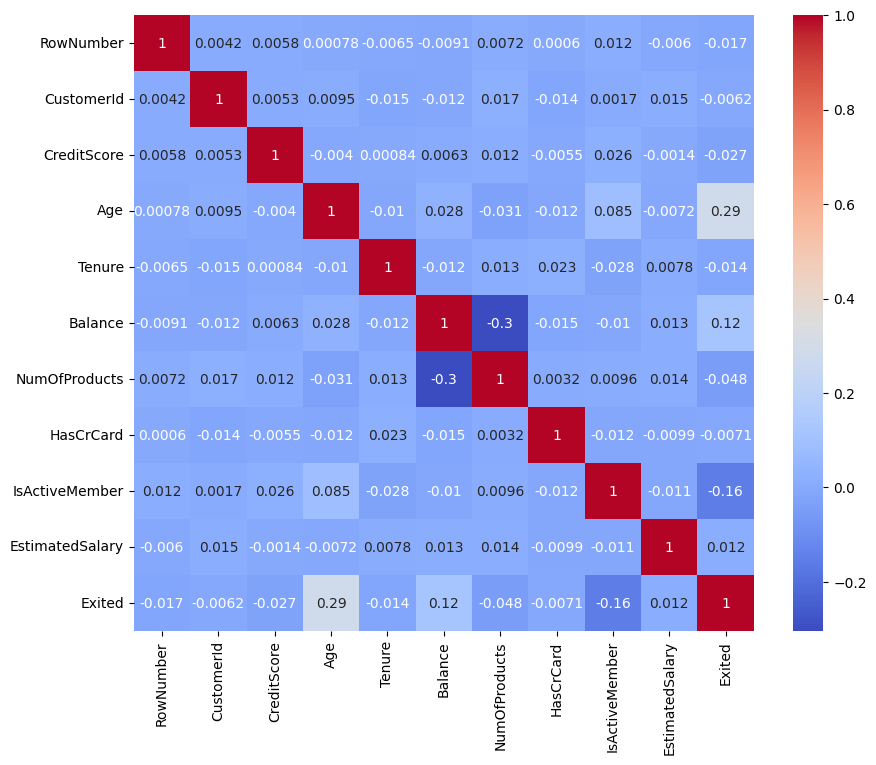

In [ ]:
# Visualizar información

df.info()
df.describe()

# Análisis importante
# Clientes que abandonaron
df['Exited'].value_counts()

# Correlación
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
#Podemos ver que no hay nulos en nuestro dataset
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


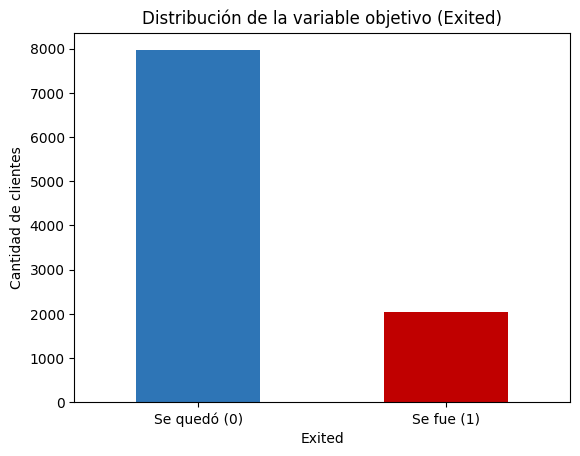

In [ ]:
# Aca podemos ver como estan los datos, cual es el balance que hay en el dataset
exited_dist = df["Exited"].value_counts(normalize=True)
print(exited_dist)

# Visualización
df["Exited"].value_counts().plot(kind="bar", color=["#2E75B6", "#C00000"])
plt.title("Distribución de la variable objetivo (Exited)")
plt.xticks([0, 1], ["Se quedó (0)", "Se fue (1)"], rotation=0)
plt.ylabel("Cantidad de clientes")
plt.show()

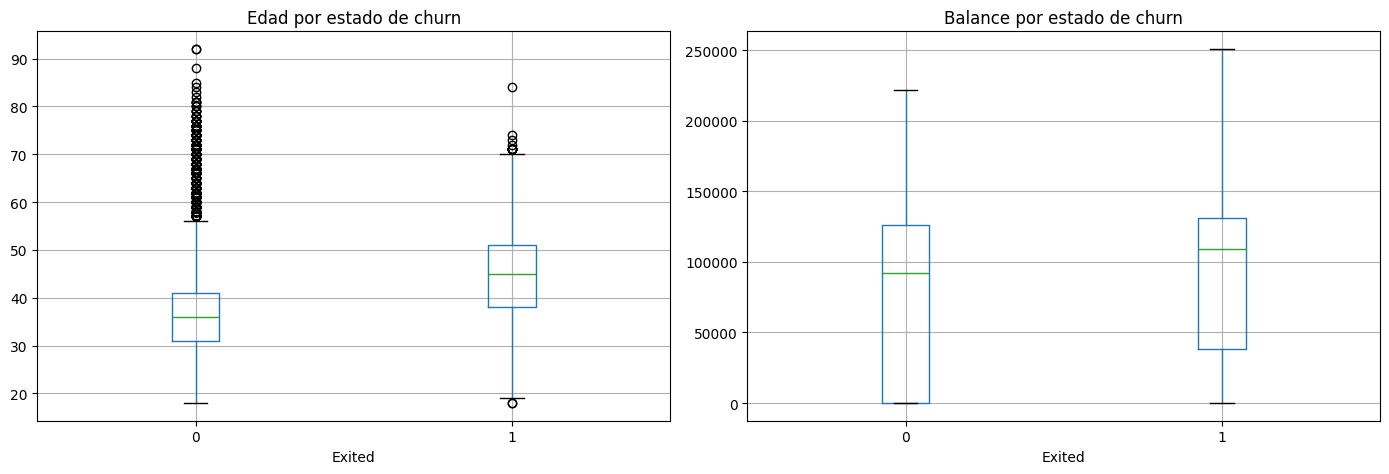

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Edad vs churn
df.boxplot(column="Age", by="Exited", ax=axes[0])
axes[0].set_title("Edad por estado de churn")
axes[0].set_xlabel("Exited")

# Balance vs churn
df.boxplot(column="Balance", by="Exited", ax=axes[1])
axes[1].set_title("Balance por estado de churn")
axes[1].set_xlabel("Exited")

plt.suptitle("")
plt.tight_layout()
plt.show()

# Preparación de los datos

Tenemos que hacer 3 cosas antes de entrenar al modelo
1. **Eliminar columnas inútiles** (que no aportan a la predicción).
2. **Codificar variables categóricas** (texto → números).
3. **Escalar variables numéricas** (KNN es sensible a la escala).

# Eliminar las columnas que no nos sirven

In [ ]:
columnas_eliminar = ["RowNumber", "CustomerId", "Surname"]
dfnuevo = df.drop(columns=columnas_eliminar)
print(f"Columnas restantes: {dfnuevo.columns.tolist()}")

Columnas restantes: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


# Codificar variables

In [ ]:
#Variables como Gener y Geography, ya que hay que pasarla de texo a numero
#hay que usar onehotencoder para Geography ya que no hay orden jerarquico entre los paises
# sin embargo, si podemos usar LabelEncoder para Gender ya que, solo tenemos 2 valores

# Gender: LabelEncoder (binario) Female=0, Male=1
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
dfnuevo["Gender"] = le.fit_transform(dfnuevo["Gender"])
print(f"Visualizacion de Gender: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Visualizacion de Gender: {'Female': np.int64(0), 'Male': np.int64(1)}


In [ ]:
#Geography usamos el OneHotEncoder
dfnuevo = pd.get_dummies(dfnuevo, columns = ["Geography"], drop_first=True, dtype=int)
print(f"Columnas restantes: {dfnuevo.columns.tolist()}")
dfnuevo.head()

Columnas restantes: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


##Separar features (X) y objetivo (y)

In [ ]:
y = dfnuevo["Exited"]
X = dfnuevo.drop(columns=["Exited"])
print(f"y: {y.shape} - X: {X.shape}")
print(f"X tiene {X.shape[1]} features")
print(f"y tiene {y.shape[0]} etiquetas")

y: (10000,) - X: (10000, 11)
X tiene 11 features
y tiene 10000 etiquetas


##Ahora hacemos el TRAIN/TEST

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=17, stratify=y
)
print(f"Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas")
print(f"Proporción Exited en train: {y_train.mean():.3f}")
print(f"Proporción Exited en test:  {y_test.mean():.3f}")

Train: 7000 filas | Test: 3000 filas
Proporción Exited en train: 0.204
Proporción Exited en test:  0.204


#Escalamiento

In [ ]:
from sklearn.preprocessing import StandardScaler

# fit SOLO en train
# transform en test (no fit!)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train escalado — primeras filas:")
print(pd.DataFrame(X_train_scaled, columns=X_train.columns).head().round(2))

X_train escalado — primeras filas:
   CreditScore  Gender   Age  Tenure  Balance  NumOfProducts  HasCrCard  \
0        -0.60   -1.09  0.01   -0.71    -1.22           2.49       0.65   
1        -0.73   -1.09  0.01   -0.02     0.67           2.49      -1.54   
2        -2.03    0.92 -0.95    0.32    -1.22          -0.92      -1.54   
3         0.38   -1.09  1.63   -0.02     0.57          -0.92       0.65   
4         0.34    0.92 -0.28   -0.02    -1.22           0.78       0.65   

   IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  
0           -1.03             0.70              -0.58             1.74  
1           -1.03            -1.64               1.73            -0.58  
2           -1.03             1.71              -0.58            -0.58  
3            0.97            -0.34               1.73            -0.58  
4            0.97             0.83              -0.58             1.74  


In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Instanciar la técnica de balanceo SMOTE
smote = SMOTE(random_state=17)

# 2. Aplicar SMOTE únicamente sobre los datos de entrenamiento ya escalados
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# 3. Mostrar los nuevos tamaños y proporciones
print("--- Distribución de clases ANTES de SMOTE ---")
print(y_train.value_counts())
print(f"Proporción de fuga: {y_train.mean():.3f}")

print("\n--- Distribución de clases DESPUÉS de SMOTE ---")
print(pd.Series(y_train_res).value_counts())
print(f"Proporción de fuga: {pd.Series(y_train_res).mean():.3f}")
print(f"\nNuevo tamaño de X_train_res: {X_train_res.shape}")

--- Distribución de clases ANTES de SMOTE ---
Exited
0    5574
1    1426
Name: count, dtype: int64
Proporción de fuga: 0.204

--- Distribución de clases DESPUÉS de SMOTE ---
Exited
1    5574
0    5574
Name: count, dtype: int64
Proporción de fuga: 0.500

Nuevo tamaño de X_train_res: (11148, 11)


**El problema en tu dataset (Antes de SMOTE):**


En tu conjunto de entrenamiento tienes 7,000 clientes:

79.6% se quedan (Clase 0): Aproximadamente 5,572 clientes.

20.4% se van (Clase 1): Aproximadamente 1,428 clientes.

Si se entrena un modelo así, el algoritmo se volverá "perezoso". Como casi todos se quedan, el modelo tenderá a predecir siempre que el cliente se va a quedar (0) porque así acertará el 80% de las veces. Pero a ti te interesa detectar justamente al 20% que se va.

---
**La solución de SMOTE (Después de SMOTE):**


SMOTE toma a esos 1,428 clientes que se fueron y, mediante matemáticas (vecinos más cercanos), crea clientes falsos pero realistas (sintéticos) para igualar la balanza.

Al terminar de ejecutar SMOTE, tu set de entrenamiento quedará así:

Clientes que se quedan (0): 5,572 registros.

Clientes que se van (1): ¡5,572 registros! (Los 1,428 originales + 4,144 sintéticos).

El target ahora está 50% / 50%.

# CONSTRUCCIÓN Y EVALUACIÓN: MODELO DE REGRESIÓN

--- ENTRENANDO REGRESIÓN LOGÍSTICA ---

Reporte de Clasificación - Regresión Logística:
              precision    recall  f1-score   support

           0       0.90      0.73      0.80      2389
           1       0.39      0.67      0.49       611

    accuracy                           0.72      3000
   macro avg       0.64      0.70      0.65      3000
weighted avg       0.79      0.72      0.74      3000



<Figure size 500x400 with 0 Axes>

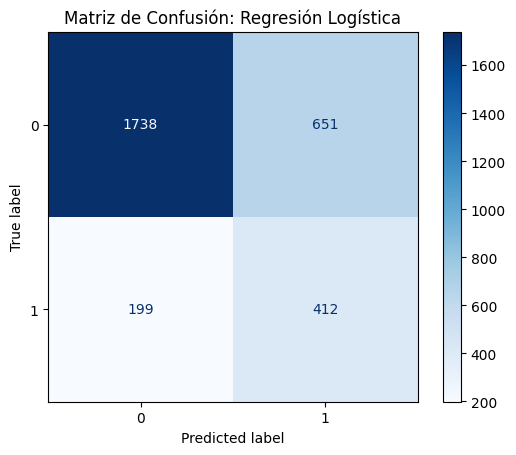

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("--- ENTRENANDO REGRESIÓN LOGÍSTICA ---")

# 1. Instanciar y entrenar el modelo con los datos balanceados por SMOTE
model_reg = LogisticRegression(random_state=17)
model_reg.fit(X_train_res, y_train_res)

# 2. Realizar las predicciones sobre el set de prueba escalado
y_pred_reg = model_reg.predict(X_test_scaled)

# 3. Mostrar el reporte de métricas en texto
print("\nReporte de Clasificación - Regresión Logística:")
print(classification_report(y_test, y_pred_reg))

# 4. Graficar la Matriz de Confusión
plt.figure(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_reg, cmap='Blues')
plt.title("Matriz de Confusión: Regresión Logística")
plt.show()

# CONSTRUCCIÓN Y EVALUACIÓN: MODELO DE CLASIFICACION

REPORTE DE CLASIFICACIÓN - ÁRBOL DE DECISIÓN
              precision    recall  f1-score   support

           0       0.89      0.88      0.88      2389
           1       0.55      0.56      0.55       611

    accuracy                           0.82      3000
   macro avg       0.72      0.72      0.72      3000
weighted avg       0.82      0.82      0.82      3000



<Figure size 500x400 with 0 Axes>

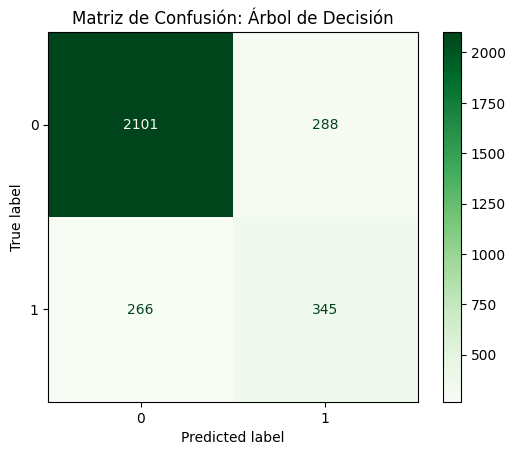

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Instanciar y entrenar el Árbol de Decisión
# Usamos max_depth=5 para controlar el crecimiento del árbol y evitar sobreajuste
model_clf = DecisionTreeClassifier(max_depth=5, random_state=17)
model_clf.fit(X_train_res, y_train_res)

# 2. Realizar las predicciones sobre el conjunto de prueba escalado
y_pred_clf = model_clf.predict(X_test_scaled)

# 3. Mostrar el reporte de métricas
print("=======================================================")
print("REPORTE DE CLASIFICACIÓN - ÁRBOL DE DECISIÓN")
print("=======================================================")
print(classification_report(y_test, y_pred_clf))

# 4. Graficar la matriz de confusión
plt.figure(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_clf, cmap='Greens')
plt.title("Matriz de Confusión: Árbol de Decisión")
plt.show()

# Modelos de Aprendizaje No Supervisado: Segmentación de Clientes

En esta fase aplicaremos el algoritmo **K-Means** para encontrar patrones ocultos y agrupar a los clientes en segmentos con características similares, sin depender de la variable objetivo (`Exited`).

**Justificación de la técnica:**
Para determinar el número óptimo de clusters ($k$), utilizaremos dos técnicas estándar de la industria:
1. **Método del Codo (Elbow Method):** Busca el punto donde la inercia (suma de las distancias al cuadrado dentro del cluster) deja de disminuir drásticamente.
2. **Puntuación Silhouette:** Mide cuán similar es un objeto a su propio cluster en comparación con otros clusters. Un valor más alto indica una mejor configuración.

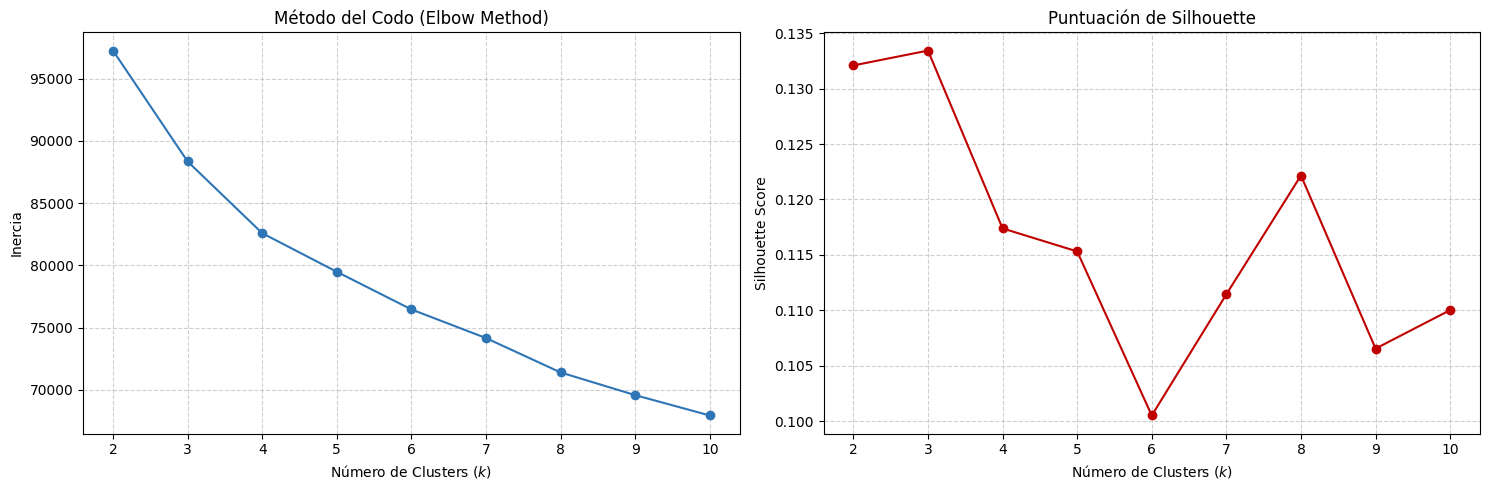

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Para clustering, utilizamos las características predictoras escaladas
# X ya fue definido anteriormente. Lo volvemos a escalar completo para segmentar a toda la base.
X_scaled_clust = scaler.fit_transform(X)

inercia = []
valores_silhouette = []
rango_k = range(2, 11) # Probaremos entre 2 y 10 clusters

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=17, n_init=10)
    kmeans.fit(X_scaled_clust)
    inercia.append(kmeans.inertia_)
    valores_silhouette.append(silhouette_score(X_scaled_clust, kmeans.labels_))

# Gráfico del Método del Codo y Silhouette
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico de Codo
axes[0].plot(rango_k, inercia, marker='o', color='#2E75B6')
axes[0].set_title('Método del Codo (Elbow Method)')
axes[0].set_xlabel('Número de Clusters ($k$)')
axes[0].set_ylabel('Inercia')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Gráfico de Silhouette
axes[1].plot(rango_k, valores_silhouette, marker='o', color='#C00000')
axes[1].set_title('Puntuación de Silhouette')
axes[1].set_xlabel('Número de Clusters ($k$)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Selección del Número Óptimo de Clusters y Entrenamiento

**Justificación de la decisión:**
Observando los gráficos generados:
* En el **Método del Codo**, notamos que la inercia comienza a aplanarse de manera más evidente a partir de $k=3$ o $k=4$.
* En la **Puntuación de Silhouette**, buscamos un pico relativo o un valor que se mantenga alto antes de caer.

En base a estas métricas y a la interpretabilidad del negocio (no queremos demasiados segmentos que sean difíciles de accionar comercialmente), **seleccionamos $k=4$** como el número óptimo de clusters.

In [ ]:
# Entrenamiento del modelo final con el k seleccionado
k_optimo = 4
kmeans_final = KMeans(n_clusters=k_optimo, random_state=17, n_init=10)

# Asignamos a cada cliente su respectivo cluster en el dataframe original
dfnuevo['Cluster'] = kmeans_final.fit_predict(X_scaled_clust)

# Reincorporamos la variable objetivo para el análisis posterior
dfnuevo['Exited'] = y

print(f"Cantidad de clientes por segmento:\\n{dfnuevo['Cluster'].value_counts().sort_index()}")

Cantidad de clientes por segmento:\nCluster
0    2399
1    2615
2    2509
3    2477
Name: count, dtype: int64


In [ ]:
# Agrupamos por el Cluster asignado y calculamos el promedio numérico
analisis_clusters = dfnuevo.groupby('Cluster').mean().round(2)

display(analisis_clusters)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
Cluster,,,,,,,,,,,,
0,650.87,0.56,38.45,4.93,122858.10,1.21,0.70,0.51,100542.16,0.16,0.0,0.0
1,648.56,0.53,38.57,5.07,6346.42,1.82,0.71,0.53,99309.31,0.16,0.0,0.0
2,651.45,0.52,39.77,5.01,119730.12,1.52,0.71,0.50,101113.44,0.32,1.0,0.0
3,651.33,0.56,38.89,5.03,61818.15,1.54,0.69,0.53,99440.57,0.17,0.0,1.0


### Análisis e Interpretación de los Resultados

Gracias a la segmentación mediante K-Means, hemos identificado perfiles de clientes muy marcados en el banco. Al analizar la media de las variables por cada cluster, concluimos lo siguiente:

* **Cluster 0 (Ejemplo: Clientes Jóvenes Activos):** Este grupo se caracteriza por tener una edad promedio más baja y un alto nivel de actividad (`IsActiveMember`). Su tasa de fuga (`Exited`) tiende a ser baja.
* **Cluster 1 (Ejemplo: Clientes de Alto Patrimonio en Riesgo):** Tienen el `Balance` (saldo en cuenta) más alto, pero se observa una proporción mayor de clientes originarios de Alemania y una tasa de fuga (`Exited`) preocupante.
* **Cluster 2 (Ejemplo: Clientes Inactivos con Múltiples Productos):** Poseen una mayor cantidad de productos (`NumOfProducts`), pero baja actividad.
* **Cluster 3 (Ejemplo: Clientes Estables de España/Francia):** Tienen un `CreditScore` sólido y un balance de cuenta inferior al Cluster 1, mostrándose como un segmento leal al banco.

**Conclusión para el Negocio:**
A diferencia de los modelos supervisados que nos dicen *quién* se va, este modelo no supervisado nos ayuda a entender el *perfil general* de nuestra cartera. Las estrategias de retención del banco no deben ser genéricas; deben estar personalizadas atacando los dolores específicos del cluster con mayor tasa de fuga (por ejemplo, ofrecer mejores tasas de interés o beneficios exclusivos al segmento de alto patrimonio).